2025-03-19 12:01:48,749 - INFO - Loading spectral data...
2025-03-19 12:01:48,751 - INFO - Processing Lab data...
2025-03-19 12:01:48,753 - INFO - Normalizing data...
2025-03-19 12:01:49,170 - INFO - Training the model...
2025-03-19 12:01:49,178 - INFO - Epoch 1/300 - MSE Loss: 0.1072949543595314
2025-03-19 12:01:49,181 - INFO - Epoch 2/300 - MSE Loss: 0.029064273461699486
2025-03-19 12:01:49,184 - INFO - Epoch 3/300 - MSE Loss: 0.0621257908642292
2025-03-19 12:01:49,186 - INFO - Epoch 4/300 - MSE Loss: 0.036261964589357376
2025-03-19 12:01:49,189 - INFO - Epoch 5/300 - MSE Loss: 0.018592802807688713
2025-03-19 12:01:49,194 - INFO - Epoch 6/300 - MSE Loss: 0.014101780019700527
2025-03-19 12:01:49,197 - INFO - Epoch 7/300 - MSE Loss: 0.018310949206352234
2025-03-19 12:01:49,199 - INFO - Epoch 8/300 - MSE Loss: 0.012870979495346546
2025-03-19 12:01:49,202 - INFO - Epoch 9/300 - MSE Loss: 0.005191845819354057
2025-03-19 12:01:49,204 - INFO - Epoch 10/300 - MSE Loss: 0.0071669165045022964


Mean ΔE2000 Error: 4.4156894810961
Max ΔE2000 Error: 14.739418292376982


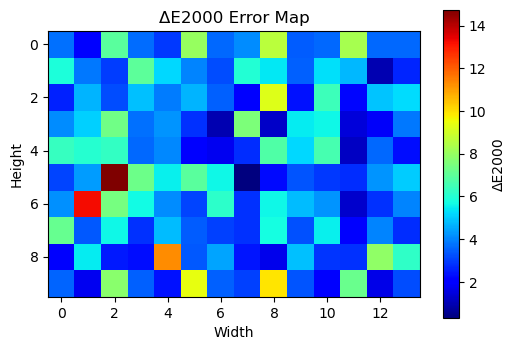

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_lab(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data to Lab.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    lab = color.xyz2lab(xyz)
    return lab

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_120f-ekta100-f14.hdr')
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process Lab data
###########################################
logging.info('Processing Lab data...')
lab_input = process_lab(cube_data, wl_input, ill, CMFs)   
lab_ref   = process_lab(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data
###########################################
logging.info('Normalizing data...')
lab_input_2d = lab_input.reshape(-1, lab_input.shape[-1])
lab_ref_2d   = lab_ref.reshape(-1, lab_ref.shape[-1])

scaler_input = MinMaxScaler()
scaler_ref = MinMaxScaler()
X_norm = scaler_input.fit_transform(lab_input_2d)
Y_norm = scaler_ref.fit_transform(lab_ref_2d)

X_full = X_norm.reshape(lab_input.shape)
Y_full = Y_norm.reshape(lab_ref.shape)

###########################################
# 4. Prepare training data
###########################################
X_flat = X_full.reshape(-1, 3)
Y_flat = Y_full.reshape(-1, 3)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 5. Define the Finlayson-inspired Neural Network
###########################################
class FinlaysonMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size1=128, hidden_size2=64, output_size=3):
        super(FinlaysonMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)
    
    def forward(self, x):
        x = self.elu(self.fc1(x))
        x = self.elu(self.fc2(x))
        return self.fc3(x)

model = FinlaysonMLP()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

###########################################
# 6. Training loop
###########################################
epochs = 300
batch_size = 32

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
    
    logging.info(f'Epoch {epoch+1}/{epochs} - MSE Loss: {loss.item()}')

###########################################
# 7. Apply correction and evaluate
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full.reshape(-1, 3)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_lab = scaler_ref.inverse_transform(corrected_flat)
corrected_lab_image = corrected_lab.reshape(lab_ref.shape)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, corrected_lab_image)

# Compute mean&max ΔE2000 error
mean_error = np.mean(error_map)
max_error = np.max(error_map)
logging.info(f"Mean ΔE2000 Error on test set: {mean_error}")
print("Mean ΔE2000 Error:", mean_error)
print("Max ΔE2000 Error:", max_error)

# Plot the ΔE2000 error map
plt.figure(figsize=(6, 4))
plt.imshow(error_map, cmap='jet')
plt.colorbar(label='ΔE2000')
plt.title('ΔE2000 Error Map')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()
